# 05. Model Interpretation, ROC Evaluation & SHAP Analysis
Compute ROC performance curves, SHAP summary plots, feature importances, and partial dependence insights for F1 pit stop drivers.


In [1]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from src.data import load_raw_data
from src.features import create_features
from lightgbm import LGBMClassifier


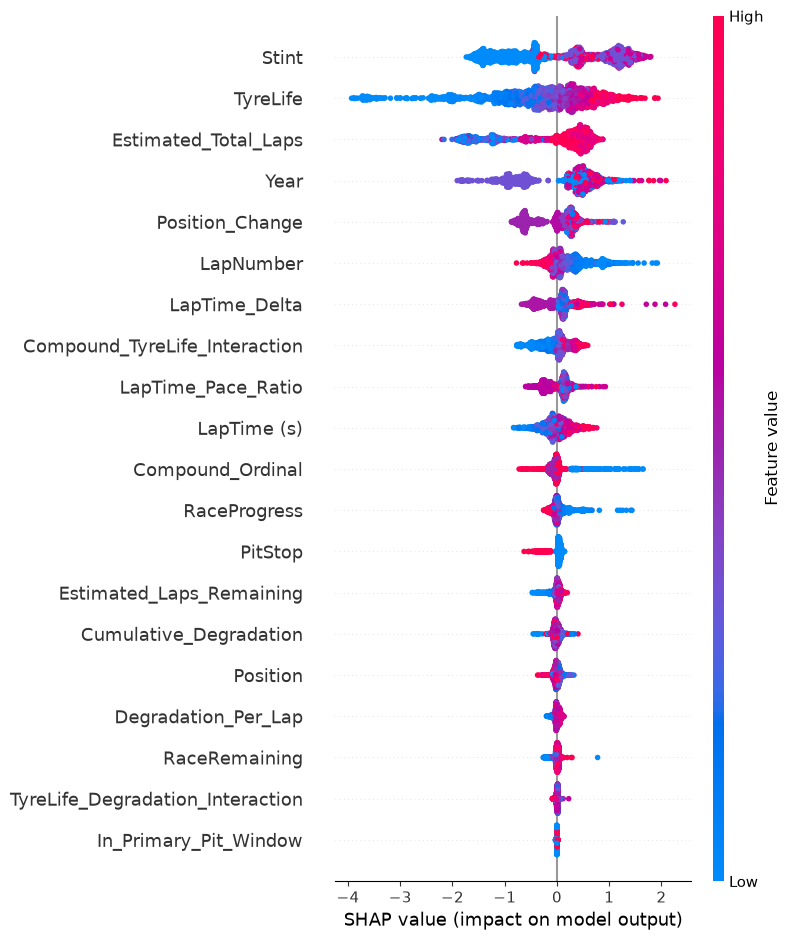

In [2]:
train, _, _ = load_raw_data('../data/raw')
train_feat, fcols = create_features(train)
X = train_feat[fcols]
y = train_feat['PitNextLap'].values

lgb = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1)
lgb.fit(X, y)

explainer = shap.TreeExplainer(lgb)
sample_X = X.sample(2000, random_state=42)
shap_values = explainer(sample_X)
shap.summary_plot(shap_values, sample_X)
